<a href="https://colab.research.google.com/github/noorbrar884-pixel/MuthootFinanaceNoorBrar/blob/main/CA3projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                   Equity Capital  Reserves  Borrowing  Other Liabilities  \
Equity Capital           1.000000  0.697718   0.615119           0.140141   
Reserves                 0.697718  1.000000   0.968764           0.716589   
Borrowing                0.615119  0.968764   1.000000           0.781634   
Other Liabilities        0.140141  0.716589   0.781634           1.000000   
TotalLiabilities         0.630115  0.980295   0.998568           0.779292   
Fixed Assets             0.505204  0.940728   0.969921           0.805593   
CWIP                     0.528187  0.391292   0.173826          -0.040369   
Investments              0.402193  0.793962   0.912005           0.772392   
Other Assets             0.635895  0.982969   0.997706           0.776383   
Total Assets             0.630115  0.980295   0.998568           0.779292   
TAD                      0.648886  0.711384   0.650674           0.325133   

                   TotalLiabilities  Fixed Assets      CWIP  Investments  \

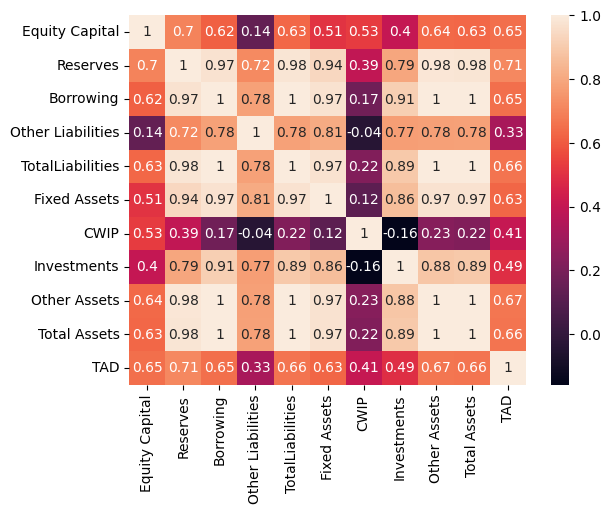

In [2]:
#noordeep #12529314
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"/content/MUTHOOTFIN (1).csv")

c = df.corr(numeric_only=True)
print(c)


sns.heatmap(c, annot=True)
plt.show()

Heatmap Analysis

                            OLS Regression Results                            
Dep. Variable:           Fixed Assets   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.566e+05
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.43e-08
Time:                        19:40:28   Log-Likelihood:                0.40995
No. Observations:                  12   AIC:                             17.18
Df Residuals:                       3   BIC:                             21.54
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.9417    147.433  

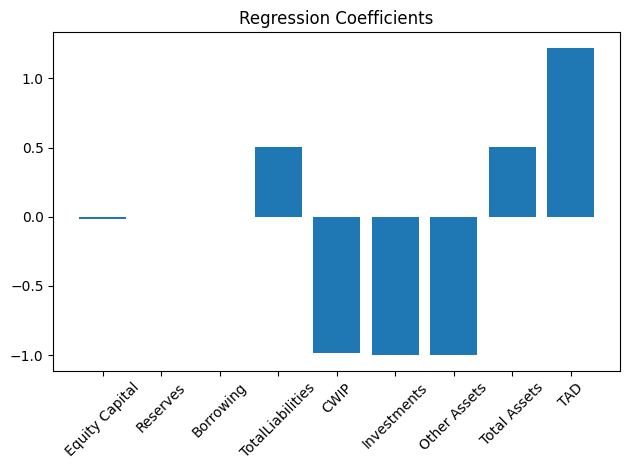

In [3]:
# Noordeep 12529314

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv(r"/content/MUTHOOTFIN (1).csv")
df.columns = df.columns.str.strip()

fa = [c for c in df.columns if "fixed" in c.lower() and "asset" in c.lower()][0]

y = df[fa]

x = df.select_dtypes("number").drop(columns=[fa], errors='ignore')

x = x.drop(columns=[c for c in x.columns if "other" in c.lower() and "liab" in c.lower()], errors='ignore')

model = sm.OLS(y, sm.add_constant(x), missing='drop').fit()

print(model.summary())

coef = model.params.drop("const", errors='ignore')

plt.bar(coef.index, coef.values)

plt.xticks(rotation=45)

plt.title("Regression Coefficients")

plt.tight_layout()

plt.show()

Regression

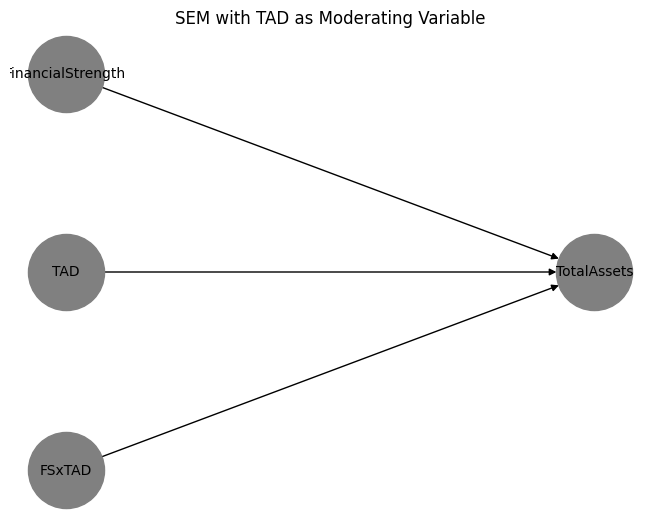

In [4]:
# Noordeep 12529314

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv(r"/content/MUTHOOTFIN (1).csv").dropna()

df = df.select_dtypes(include="number")

y = "TotalAssets"

moderator = "TAD"

explanatory = [c for c in df.columns if c not in [y, moderator]]

df["FinancialStrength"] = df[explanatory].mean(axis=1)

df["FSxTAD"] = df["FinancialStrength"] * df[moderator]

G = nx.DiGraph()

G.add_edge("FinancialStrength", "TotalAssets")

G.add_edge("TAD", "TotalAssets")

G.add_edge("FSxTAD", "TotalAssets")

pos = {
    "FinancialStrength": (0, 1),
    "TAD": (0, 0),
    "FSxTAD": (0, -1),
    "TotalAssets": (2, 0)
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="gray",
    font_size=10,
    arrows=True
)

plt.title("SEM with TAD as Moderating Variable")

plt.show()

SEM

R2 Score : 0.8191922849842318
RMSE     : 18669.58630143332


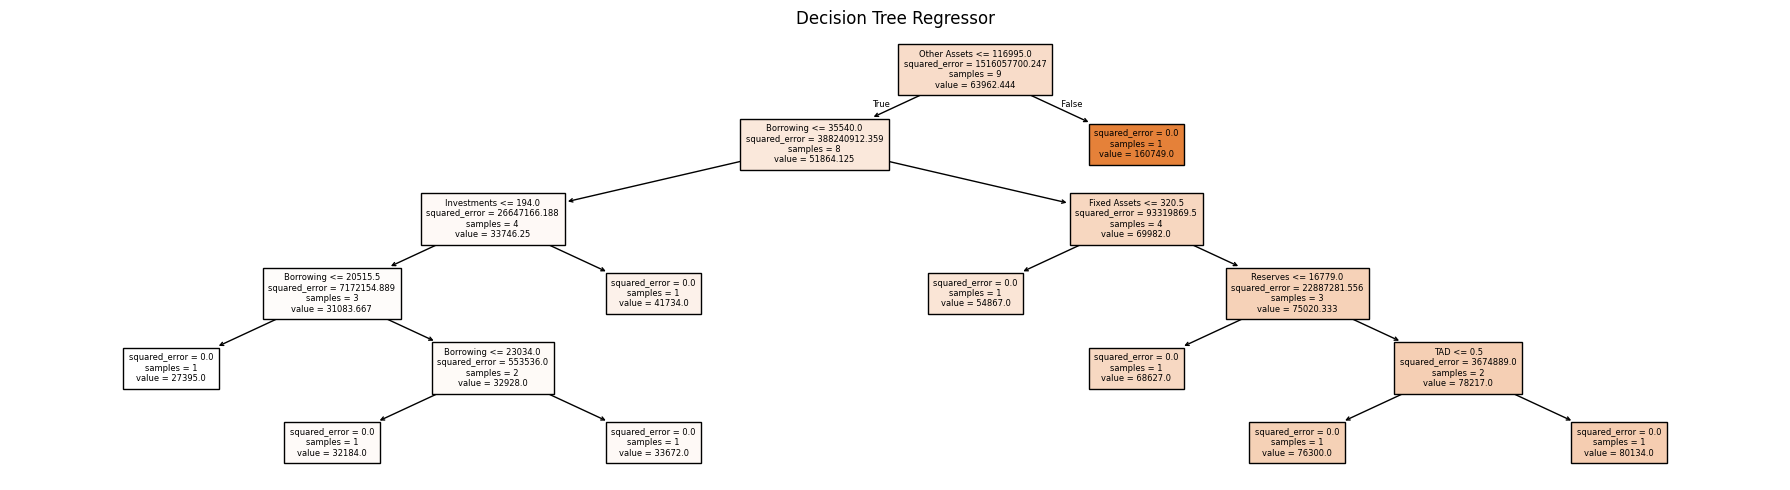

In [12]:
# Noordeep 12529314

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from google.colab import files
import io

df = pd.read_csv(r"/content/MUTHOOTFIN (1).csv")

df = df.drop(columns=["Year"])

X = df.drop(columns=["Total Assets"])
y = df["Total Assets"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R2 Score :", r2_score(y_test, y_pred))
print("RMSE     :", mean_squared_error(y_test, y_pred) ** 0.5)

plt.figure(figsize=(18, 5))
plot_tree(model, feature_names=X.columns.tolist(), filled=True, fontsize=6)
plt.title("Decision Tree Regressor")
plt.tight_layout()
plt.show()

ML